<a href="https://colab.research.google.com/github/mhasan502/Age_Estimation/blob/Jibon/Age_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing Required Packages

In [16]:
### --- For Connecting Google Colab with Local Host --- ###
# pip install jupyter_http_over_ws
## jupyter serverextension enable --py jupyter_http_over_ws
## jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0

!pip install tqdm
!pip install parse
!pip install opencv-python
!pip install autocrop
!pip install -U albumentations

# Importing Required Packages

In [17]:
import os
import sys
import string
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
from parse import parse
from autocrop import Cropper
from IPython.display import clear_output

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Scale, Grayscale, Resize, transforms

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#import warnings
#warnings.filterwarnings("ignore")

# device = torch.device("cpu")
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [18]:
torch.backends.cudnn.benchmark = True

In [19]:
torch.cuda.device_count()

1

In [20]:
!nvidia-smi -L 

GPU 0: NVIDIA GeForce 920MX (UUID: GPU-38bea3f0-6644-d822-3fce-ca69b5e03f7d)


In [21]:
cuda_sum = torch.cuda.memory_summary(torch.device("cuda"), abbreviated=False)
print(cuda_sum)

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |       0 B  |       0 B  |       0 B  |       0 B  |
|       from large pool |       0 B  |       0 B  |       0 B  |       0 B  |
|       from small pool |       0 B  |       0 B  |       0 B  |       0 B  |
|---------------------------------------------------------------------------|
| Active memory         |       0 B  |       0 B  |       0 B  |       0 B  |
|       from large pool |       0 B  |       0 B  |       0 B  |

In [22]:
#torch.cuda.empty_cache()



---



# Hyperparameters Setting

In [176]:
### --- Hyperparameters --- ###

input_size = 64                                      # 128
num_channels = 3
hidden_units = 32                                    # 
num_classes = 117                                    # total possible outputs
learning_rate = 0.001                                # 
num_epochs = 10                                      # epoch = 1-forward and backward pass of ALL training samples
batch_size = 64                                      # batch_size = number of training samples in one forward & backward pass
#step_size = 10                                      # number of iterations = number of passes, each pass using [batch_size] number of samples
                                                     # e.g. 100 samples, batch_size=20 --> 100/20 = 5 iterations for 1 epoch



---



# 1. Data Preparation

## a. Transformation

In [24]:
### --- Data Transformation using Albumentations as A --- ###

transformA = A.Compose([A.Resize(input_size, input_size),
                       A.ToGray(p=1),
                       A.Rotate(limit=10, p=0.3),
                       A.HorizontalFlip(p=0.4),
                       A.OpticalDistortion(p=0.2),
                       A.OneOf([A.Blur(blur_limit=3, p=0.2),
                                A.ColorJitter(p=0.2),                                
                       ], p=0.2),
                       ToTensorV2()
])

## a. Import Data



In [25]:
### --- From Google Drive --- ###

#from google.colab import drive
#drive.mount('/content/gdrive')

In [26]:
# give appropriate location
#directoryAgeDB = '/content/gdrive/MyDrive/Colab Notebooks/AgeDBDataset/AgeDB'
directoryAgeDB = 'AgeDB/'

In [27]:
inside1 = os.listdir(directoryAgeDB)
#inside1 = sorted(os.listdir(directoryAgeDB))

print("AgeDB:")
for i in range(10):
    print(inside1[i])

AgeDB:
0_MariaCallas_35_f.jpg
10000_GlennClose_62_f.jpg
10001_GoldieHawn_23_f.jpg
10002_GoldieHawn_24_f.jpg
10003_GoldieHawn_24_f.jpg
10004_GoldieHawn_27_f.jpg
10005_GoldieHawn_28_f.jpg
10006_GoldieHawn_29_f.jpg
10007_GoldieHawn_30_f.jpg
10008_GoldieHawn_31_f.jpg


## b. DataLoader

### * AgeDB

In [28]:
### --- AgeDB Dataset Class --- ###           {}_{person}_{age}_{gender}.jpg

class AgeDBDataset(Dataset):

## data loading
  def __init__(self, directory, device, transform=None, **kwargs):
    self.directory = directory
    self.transform = transform
    self.device = device
    self.labels = []
    self.images = []
    
    gender_to_class_id = {
                          'm': 0,
                          'f': 1
    }

    for i, file in enumerate(sorted(os.listdir(self.directory))):
      file_labels = parse('{}_{person}_{age}_{gender}.jpg', file)

      if file_labels is None:
        continue

      image = Image.open(os.path.join(self.directory, file)).convert('RGB')
    
########
      cropper = Cropper()
      
      try: 
        #Get a Numpy array of the cropped image
        cropped_array = cropper.crop(image)
        #Save the cropped image with PIL
        image = Image.fromarray(cropped_array)
        
      except:
        pass
      
      image = np.array(image)

      for i in range(3):
        augmented_images = self.transform(image=image)['image']
        self.images.append(augmented_images)
########
        gender = gender_to_class_id[file_labels['gender']]
        person = str(file_labels['person'])
        age = int(file_labels['age'])
        self.labels.append({
                            'person': person,
                            'age': age, 
                            'gender': gender
        })

## len(dataset)
  def __len__(self):
    return len(self.labels)

## dataset[0]
  def __getitem__(self, index):
    if torch.is_tensor(index):
      index = index.tolist()

    image = self.images[index]

    labels = {
             'person': self.labels[index]['person'], 
             'age': self.labels[index]['age'], 
             'gender': self.labels[index]['gender']
    }

    return image.to(self.device), labels

## DataLoaders - train, validate, test
  def get_loaders(self, batch_size, train_size, test_size, random_seed, **kwargs):
    train_len = int(len(self) * train_size)
    test_len = int(len(self) * test_size)
    validate_len = len(self) - (train_len + test_len)

    self.trainDataset, self.validateDataset, self.testDataset = torch.utils.data.random_split(
      dataset = self, 
      lengths = [train_len, validate_len, test_len],
      generator = torch.Generator().manual_seed(random_seed)
    )

    train_loader = DataLoader(self.trainDataset, batch_size=batch_size)
    validate_loader = DataLoader(self.validateDataset, batch_size=batch_size)
    test_loader = DataLoader(self.testDataset, batch_size=batch_size)

    return train_loader, validate_loader, test_loader


## Dataset Assigned

In [45]:
#### --- For AgeDB Dataset --- ###

datasetAgeDB = AgeDBDataset(directory = directoryAgeDB,
                       device = device,
                       transform = transformA
)

## e. Data Splitting 

In [46]:
train_loader, validation_loader, test_loader = datasetAgeDB.get_loaders(
    batch_size = batch_size,
    train_size = 0.7,
    test_size = 0.2,
    random_seed = 42
)

## e. EDA - Exploratory Data Analysis

In [47]:
datasetAgeDB

In [48]:
print(len(datasetAgeDB))

49464


In [49]:
print(datasetAgeDB[49463])

(tensor([[[ 18,  17,  19,  ...,  34,  33,  33],
         [ 17,  20,  23,  ...,  33,  30,  31],
         [ 18,  19,  20,  ...,  29,  30,  32],
         ...,
         [ 81,  86,  64,  ...,  44,  73, 138],
         [ 77,  79,  62,  ...,  43,  65, 130],
         [ 70,  75,  60,  ...,  39,  55, 122]],

        [[ 18,  17,  19,  ...,  34,  33,  33],
         [ 17,  20,  23,  ...,  33,  30,  31],
         [ 18,  19,  20,  ...,  29,  30,  32],
         ...,
         [ 81,  86,  64,  ...,  44,  73, 138],
         [ 77,  79,  62,  ...,  43,  65, 130],
         [ 70,  75,  60,  ...,  39,  55, 122]],

        [[ 18,  17,  19,  ...,  34,  33,  33],
         [ 17,  20,  23,  ...,  33,  30,  31],
         [ 18,  19,  20,  ...,  29,  30,  32],
         ...,
         [ 81,  86,  64,  ...,  44,  73, 138],
         [ 77,  79,  62,  ...,  43,  65, 130],
         [ 70,  75,  60,  ...,  39,  55, 122]]], device='cuda:0',
       dtype=torch.uint8), {'person': 'MariaCallas', 'age': 30, 'gender': 1})


In [50]:
def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    if torch.is_tensor(image):      
      image = np.squeeze(image) #you can give axis attribute if you wanna squeeze in specific dimension
      plt.imshow(image.permute(1, 2, 0))
    else:
      plt.imshow(image)

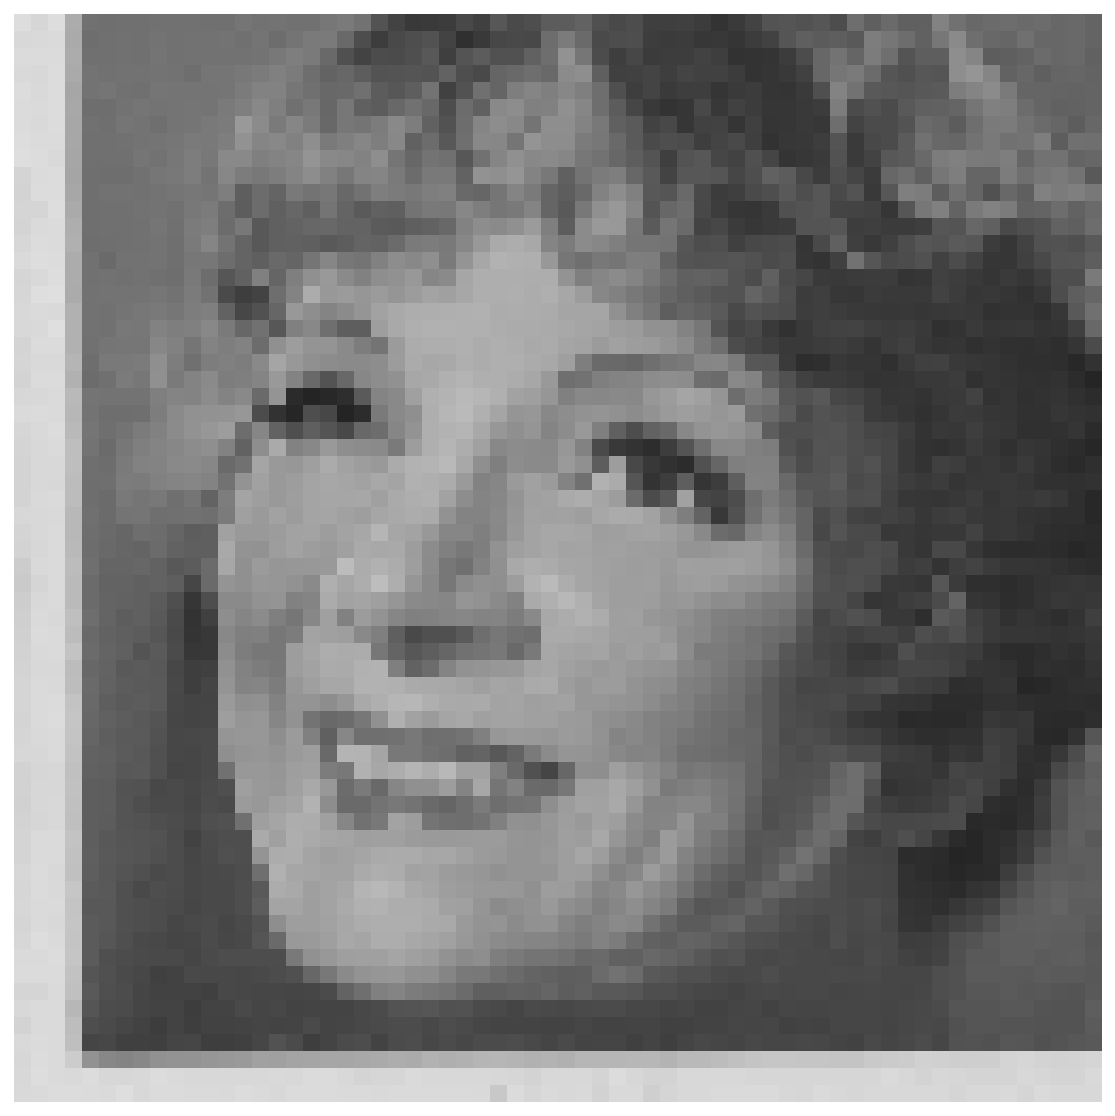

In [51]:
visualize(datasetAgeDB.images[11754])

# 2. Model

## ArcFace CNN

In [ ]:
class AngularPenaltySMLoss(nn.Module):

    def __init__(self, in_features, out_features, loss_type='arcface', eps=1e-7, s=None, m=None):
        '''
        Angular Penalty Softmax Loss
        Three 'loss_types' available: ['arcface', 'sphereface', 'cosface']
        These losses are described in the following papers: 
        
        ArcFace: https://arxiv.org/abs/1801.07698
        SphereFace: https://arxiv.org/abs/1704.08063
        CosFace/Ad Margin: https://arxiv.org/abs/1801.05599
        '''
        super(AngularPenaltySMLoss, self).__init__()
        loss_type = loss_type.lower()
        
        assert loss_type in  ['arcface', 'sphereface', 'cosface']
        
        if loss_type == 'arcface':
            self.s = 64.0 if not s else s
            self.m = 0.5 if not m else m
        if loss_type == 'sphereface':
            self.s = 64.0 if not s else s
            self.m = 1.35 if not m else m
        if loss_type == 'cosface':
            self.s = 30.0 if not s else s
            self.m = 0.4 if not m else m
            
        self.loss_type = loss_type
        self.in_features = in_features
        self.out_features = out_features
        self.fc = nn.Linear(in_features, out_features, bias=False).cuda()
        self.eps = eps

    def forward(self, x, labels):
        '''
        input shape (N, in_features)
        '''
        assert len(x) == len(labels)
        assert torch.min(labels) >= 0
        assert torch.max(labels) < self.out_features
        
        for W in self.fc.parameters():
            W = F.normalize(W, p=2, dim=1)

        x = F.normalize(x, p=2, dim=1)

        wf = self.fc(x)
        
        if self.loss_type == 'cosface':
            numerator = self.s * (torch.diagonal(wf.transpose(0, 1)[labels]) - self.m)
        if self.loss_type == 'arcface':
            numerator = self.s * torch.cos(torch.acos(torch.clamp(torch.diagonal(wf.transpose(0, 1)[labels]), -1.+self.eps, 1-self.eps)) + self.m)
        if self.loss_type == 'sphereface':
            numerator = self.s * torch.cos(self.m * torch.acos(torch.clamp(torch.diagonal(wf.transpose(0, 1)[labels]), -1.+self.eps, 1-self.eps)))

        excl = torch.cat([torch.cat((wf[i, :y], wf[i, y+1:])).unsqueeze(0) for i, y in enumerate(labels)], dim=0)
        denominator = torch.exp(numerator) + torch.sum(torch.exp(self.s * excl), dim=1)
        L = numerator - torch.log(denominator)
        return -torch.mean(L)

In [ ]:
class ConvAngularPen(nn.Module):
    def __init__(self, num_classes=117, loss_type='arcface'):
        super(ConvAngularPen, self).__init__()
        self.convlayers = ConvNet()
        self.adms_loss = AngularPenaltySMLoss(117, num_classes, loss_type=loss_type)

    def forward(self, x, labels=None, embed=False):
        x = self.convlayers(x)
        if embed:
            return x
        L = self.adms_loss(x, labels)
        return L

In [ ]:
class ConvNet(nn.Module):

    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 10, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(10))
        self.layer2 = nn.Sequential(
            nn.Conv2d(10, 15, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(15))
        self.layer3 = nn.Sequential(
            nn.Conv2d(15, 20, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(20),
            nn.MaxPool2d(kernel_size=2, stride=2))
        
        self.fc_projection = nn.Linear(18000, 117)

    def forward(self, x, embed=False):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc_projection(x)
        return x

In [ ]:
class ConvBaseline(nn.Module):
    def __init__(self, num_classes=117):
        super(ConvBaseline, self).__init__()
        self.convlayers = ConvNet()
        self.fc_final = nn.Linear(117, num_classes)

    def forward(self, x, embed=False):
        x = self.convlayers(x)
        if embed:
            return x
        x = self.fc_final(x)
        return x

In [71]:
class DCNN(nn.Module):                                     #####gradient reversal layer
    def __init__(self, num_classes = 116+1):
        super(CNN, self).__init__()
        
        
        self.unit1 = Unit(in_channels = 3, out_channels = 5)
        self.pool1 = nn.MaxPool2d(kernel_size = 2)
        self.unit2 = Unit(in_channels = 5, out_channels = 10)
        self.unit3 = Unit(in_channels = 10, out_channels = 15)
        self.pool2 = nn.MaxPool2d(kernel_size = 2)
        self.unit4 = Unit(in_channels = 15, out_channels = 20)
        self.unit5 = Unit(in_channels = 20, out_channels = 25)
        self.pool3 = nn.MaxPool2d(kernel_size = 2)
        self.unit6 = Unit(in_channels = 25, out_channels = 30)
        self.unit7 = Unit(in_channels = 30, out_channels = 35)
        self.avgpool = nn.AvgPool2d(kernel_size = 3)
        
        
        self.net = nn.Sequential(self.unit1,
                                 self.pool1, 
                                 self.unit2, 
                                 self.unit3, 
                                 self.pool2,
                                 self.unit4, 
                                 self.unit5,
                                 self.pool3,
                                 self.unit6, 
                                 self.unit7,
                                 self.avgpool)
        
        self.fc1 = nn.Sequential(nn.Linear(in_features = 140, out_features = 125),
                                 nn.LeakyReLU(),
                                 nn.Dropout(0.3),
                                 nn.Linear(in_features = 125, out_features = num_classes))

    def forward(self, input):
        output = self.net(input)
        output = output.view(-1, 140)
        output = self.fc1(output)
        return output

## CNN

In [178]:
class Unit(nn.Module):
    def __init__(self,in_channels, out_channels):
        super(Unit,self).__init__()
        
        self.conv = nn.Conv2d(in_channels = in_channels,
                              kernel_size = 3,
                              out_channels = out_channels,
                              stride = 1,
                              padding = 0)
        
        #self.bn = nn.BatchNorm2d(num_features = out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self,input):
        output = self.conv(input)
        #output = self.bn(output)
        output = self.relu(output)

        return output

In [184]:
class CNN(nn.Module):                                     #####gradient reversal layer
    def __init__(self, num_classes = 116+1):
        super(CNN, self).__init__()
        
        
        self.unit1 = Unit(in_channels = 3, out_channels = 5)
        
        self.unit2 = Unit(in_channels = 5, out_channels = 10)
        self.unit3 = Unit(in_channels = 10, out_channels = 15)
        
        
        self.avgpool = nn.AvgPool2d(kernel_size = 3)
        
        
        self.net = nn.Sequential(self.unit1,
                                 
                                 self.unit2, 
                                 self.unit3, 
                             
                                
                                 self.avgpool)
        
        self.fc1 = nn.Sequential(nn.Linear(in_features = 5415, out_features = 2000),
                                 nn.LeakyReLU(),
                                 nn.Dropout(0.3),
                                 nn.Linear(in_features = 2000, out_features = num_classes))

    def forward(self, input):
        output = self.net(input)
        output = output.view(-1, 5415)
        output = self.fc1(output)
        return output

## Using Model

In [185]:
model = CNN().to(device)

In [ ]:
#model =  ConvAngularPen(loss_type='arcface').to(device)

In [ ]:
#model = ConvNet().to(device)

In [ ]:
#model = ConvBaseline().to(device)

In [186]:
model

CNN(
  (unit1): Unit(
    (conv): Conv2d(3, 5, kernel_size=(3, 3), stride=(1, 1))
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (unit2): Unit(
    (conv): Conv2d(5, 10, kernel_size=(3, 3), stride=(1, 1))
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (unit3): Unit(
    (conv): Conv2d(10, 15, kernel_size=(3, 3), stride=(1, 1))
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (avgpool): AvgPool2d(kernel_size=3, stride=3, padding=0)
  (net): Sequential(
    (0): Unit(
      (conv): Conv2d(3, 5, kernel_size=(3, 3), stride=(1, 1))
      (relu): LeakyReLU(negative_slope=0.01)
    )
    (1): Unit(
      (conv): Conv2d(5, 10, kernel_size=(3, 3), stride=(1, 1))
      (relu): LeakyReLU(negative_slope=0.01)
    )
    (2): Unit(
      (conv): Conv2d(10, 15, kernel_size=(3, 3), stride=(1, 1))
      (relu): LeakyReLU(negative_slope=0.01)
    )
    (3): AvgPool2d(kernel_size=3, stride=3, padding=0)
  )
  (fc1): Sequential(
    (0): Linear(in_features=5415, out_features=2000, bias=True)
    (1): 

# 3. Loss function and Optimizer

In [187]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# Dont use softmax with cross entropy loss

# 4. Training Testing

## a. Training Loop

In [193]:
### --- JUST DO IT --- ###

def train(model, criterion, optimizer, train_loader, num_epochs):

  step_size = len(train_loader)
  maxi = -999999
  mini =  999999
  for epoch in range(num_epochs):
    
    for i, (imgs, labels) in enumerate(train_loader):
      
      X_train_images = imgs.to(device).float()
      y_train_ages = labels['age'].to(device)

    # Forward Pass and Loss
      y_predicted_output_scores = model(X_train_images)
      loss = criterion(y_predicted_output_scores, y_train_ages)

      maxi = max(maxi, loss)
      mini = min(mini, loss)

    # Zeros Gradients
      optimizer.zero_grad()

    # Backward Pass
      loss.backward()

    # Update Weights
      optimizer.step()

      if i % 10 == 0:
        clear_output()
      print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')

  print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, MIN LOSS: {mini:.4f}, MAX LOSS:{maxi:.4f}')

In [194]:
train(model, criterion, optimizer, train_loader, num_epochs)

EPOCH: 10/10, STEP: 541/541, LOSS: 0.1608
EPOCH: 10/10, STEP: 541/541, MIN LOSS: 0.0074234614148736, MAX LOSS:4.203761577606201


## b. Evaluate

In [198]:
def eval(model, test_loader):
  model.to(device).eval()
  step_size = len(test_loader)

  with torch.no_grad():
    correct = total = total_loss = 0
    maxi = -999999
    mini =  999999
    for imgs, labels in tqdm(test_loader):

      X_test_images = imgs.to(device).float()
      y_test_ages = labels['age'].to(device)
     
      y_predicted_output_scores = model(X_test_images)      
      _, predicted = torch.max(y_predicted_output_scores, 1)

      loss = nn.L1Loss()
      loss = loss(predicted.float(), y_test_ages)

      maxi = max(maxi, loss)
      mini = min(mini, loss)

      total_loss += loss
      total += y_test_ages.size(0)
      correct += (predicted == y_test_ages).sum().item()

  model.train()        # turn back training mode on after eval step
  print('\n')
  print(f"Accuracy: {(100 * correct) / total :.4f}%, Correct: {correct}, Total: {total}")
  print(f'Mean Average Error: {total_loss / step_size :.4f}, minimum mae: {mini:.4f}, maximum mae:{maxi:.4f}')

## c. Results

In [196]:
### --- Training Accuracy --- ###

eval(model, train_loader)

100%|████████████████████████████████████████████████████████████████████████████████| 541/541 [00:21<00:00, 24.95it/s]



Accuracy: 98.2815%, Correct: 34029, Total: 34624
Mean Average Error: 0.2374, minimum mae: 0.0, maximum mae:2.15625


In [197]:
### --- Testing Accuracy on AgeDB --- ###

eval(model, test_loader)

100%|████████████████████████████████████████████████████████████████████████████████| 155/155 [00:06<00:00, 24.67it/s]




Accuracy: 39.0720%, Correct: 3865, Total: 9892
Mean Average Error: 8.8044, minimum mae: 5.65625, maximum mae:13.078125


# Save Model

In [ ]:
PATH = 'F:/CSE465 PROJECT/Age_Estimation'
name = ''.join(random.choices(string.ascii_uppercase + string.digits, k = 5)) + '.pth'
print(name)
torch.save(model, os.path.join(PATH, 'CNNmodel.pth'))